# **LIMPIEZA DE TEXTO**

In [ ]:
#pip install python-dotenv
#pip install openai
#pip install spacy unidecode
#python -m spacy download es_core_news_sm
#pip install fonttools
#pip install -q textblob
#pip install spacy
#python -m spacy download es_core_news_sm
#pip install wordcloud
#pip install ufal.udpipe
#pip install pyspellchecker
#wget https://lindat.mff.cuni.cz/repository/xmlui/bitstream/handle/11234/1-3131/spanish-gsd-ud-2.5-191206.udpipe
#python -m spacy download es_core_news_sm
#python -m spacy download es_core_news_md
#pip install igraph

In [ ]:
from textblob import TextBlob
import spacy
nlp = spacy.load("es_core_news_sm")
from dotenv import load_dotenv
import openai
import os
import re
from nltk.corpus import stopwords
from nltk.corpus import words
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
import networkx as nx
import matplotlib.pyplot as plt
import nltk
import numpy as np
nltk.download('stopwords')
nltk.download('words')
import pandas as pd
nltk.download('punkt')
import random
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import shapiro, bartlett, pearsonr
from wordcloud import WordCloud
from nltk.probability import FreqDist
import community
import subprocess
import pickle
import igraph as ig
import unidecode
from itertools import combinations
from collections import Counter
from unidecode import unidecode
import math
nltk.download('punkt_tab')
from tqdm import tqdm
from nltk import FreqDist
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import unicodedata

In [ ]:
#FUNCIONES DE LIMPIEZA DE TEXTO

def limpiar_texto(texto):
    # Convertir texto a minúsculas
    texto = texto.lower()

    # Quitar caracteres especiales y números
    texto = re.sub(r'[^a-zA-ZñÑáéíóúÁÉÍÓÚó\s]', '', texto)
    texto = ''.join((c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn'))

    return texto

def quitar_stopwords(texto):
    tokens = word_tokenize(texto)
    texto_limpio = [word for word in tokens if word not in stop_words]

    return ' '.join(texto_limpio)


def generar_skipgramas(texto, n=2, k=2):
    tokens = word_tokenize(texto)
    skipgramas = []

    # Generar todos los pares (w_i, w_j) donde 1 ≤ j - i ≤ k + 1
    for i in range(len(tokens)):
        for j in range(i + 1, min(i + k + 2, len(tokens))):
            skipgramas.append((tokens[i], tokens[j]))

    return skipgramas


def eliminar_palabras_cortas(texto):
    excepciones = {"up", "fé", "fe"}
    palabras = texto.split()
    palabras_filtradas = [
        palabra for palabra in palabras
        if len(palabra) > 2 or palabra.lower() in excepciones
    ]
    texto_filtrado = ' '.join(palabras_filtradas)
    return texto_filtrado


In [ ]:
carpeta = 'C:/Users/Desktop/Casos_JEP/caso_06'
contenido_archivos = []
for archivo in os.listdir(carpeta):
    if archivo.endswith('.txt') and 'Rueda de prensa' not in archivo:
        ruta_archivo = os.path.join(carpeta, archivo)
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            contenido_archivos.append(f.read())
contenido_combinado= '\n'.join(contenido_archivos)
texto=contenido_combinado

#Primera lematización con palabras comunmente conocidas (ej: adverbios)
lematizaciones = {}
with open('C:/Users/Desktop/Casos_JEP/lematizacion.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones[palabra.strip()] = lema.strip()

palabras = texto.split()
palabras_lematizadas = [lematizaciones.get(palabra.lower(), palabra) for palabra in palabras]
texto_lematizado = ' '.join(palabras_lematizadas) #Obtenemos el texto nuevamente.

#Eliminar palabras cortas
texto_filtrado=eliminar_palabras_cortas(texto_lematizado)
texto_filtrado

##Tokenizar
tokens = nltk.word_tokenize(texto_filtrado, language="spanish")
texto_para_udpipe = " ".join(tokens)



# **LEMATIZACIÓN Y CORRECCIÓN PREVIA**

In [ ]:
# Lematicación con Spacy
nlp = spacy.load("es_core_news_md", disable=["parser","ner"])
excepciones = {"soldado", "voluntario"}

def lematizar_en_bloques(tokens, bloque_size=10000):
    lemas = []
    for i in tqdm(range(0, len(tokens), bloque_size)):
        bloque = tokens[i:i+bloque_size]
        docs = nlp.pipe(bloque, disable=["parser","ner"])
        for token_original, doc in zip(bloque, docs):
            token_spacy = doc[0]
            if token_original.lower() in excepciones:
                lemas.append(token_original.lower())
            else:
                lemas.append(token_spacy.lemma_)

    return lemas
lemas = lematizar_en_bloques(tokens, bloque_size=10000)

# reconstruir texto
texto_lemas = " ".join(lemas)


# **CREAR DICCIONARIO**

In [ ]:
# verificar si existen las palabras a través de un diccionario:
import re
from spellchecker import SpellChecker
spell = SpellChecker(language="es")

def limpiar_y_revisar(lemas):
    limpios = []
    typos = []

    for lema in lemas:
        palabra = lema.lower().strip()
        palabra = re.sub(r"[0-9]", "", palabra)
        if not palabra:
            continue
        if len(palabra) <= 2:
            continue
        if palabra in spell:
            limpios.append(palabra)
        else:
            typos.append(palabra)

    return limpios, typos

lemas_limpios, posibles_typos = limpiar_y_revisar(lemas)

print("Lemas válidos:", len(lemas_limpios))
print("Posibles typos:", len(posibles_typos))

In [ ]:
# Primera depuración de las palabras identificadas como typo
print(sys.getdefaultencoding())

os.environ["OPENAI_API_KEY"] = ""
client = OpenAI()
PromptInicio = (
    "Utilizando la lista de palabras proporcionada a continuación, "
    "extrae únicamente las palabras que NO pertenecen al idioma español "
    "y que parecen errores o ruido de subtítulos automáticos. "
    "No marques como errores las palabras correctas en español, "
    "aunque sean poco frecuentes.\n\n[Inicio lista]\n"
)
PromptFinal = "\n[Fin lista]\n\nResponde únicamente con una lista de los posibles errores."

def revisar_con_gpt(palabras, bloque_size=500):
    resultados = []
    n_bloques = math.ceil(len(palabras) / bloque_size)

    for i in range(n_bloques):
        bloque = palabras[i*bloque_size:(i+1)*bloque_size]
        lista_str = "\n".join(bloque)

        prompt = PromptInicio + lista_str + PromptFinal

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "Eres un asistente lingüístico experto en español."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )

        salida = response.choices[0].message.content.strip()
        resultados.append(salida)

        print(f"Bloque {i+1}/{n_bloques} procesado")

    return resultados

errores_detectados = revisar_con_gpt(posibles_typos, bloque_size=300)
ruta_errores = "C:/Users/Downloads/errores_detectados.txt" 
with open(ruta_errores, "w", encoding="utf-8") as f:
    for bloque in errores_detectados:
        f.write(bloque + "\n")

In [ ]:
# Cargar el archivo depurado previamente para depurarlo
ruta_archivo = "C:/Users/Downloads/errores_detectados.txt" 
with open(ruta_archivo, "r", encoding="utf-8") as f:
    lineas = f.readlines()

lineas_limpias = [linea.lstrip("- ").strip() for linea in lineas]
client = OpenAI()

# Prompt para corrección y lematización
PromptInicio_corr = (
    "A partir de la lista de palabras proporcionada a continuación, "
    "propón una corrección para cada palabra y redúcela a su raíz más pequeña (lema). "
    "Si la palabra no tiene significado o no se puede corregir, responde con 'NA'.\n\n"
    "[Inicio lista]\n")

PromptFinal_corr = (
    "\n[Fin lista]\n\n"
    "Responde únicamente en el formato:\n"
    "palabra_original - correccion")

def corregir_y_lematizar(palabras, bloque_size=300):
    resultados = []
    n_bloques = math.ceil(len(palabras) / bloque_size)

    for i in range(n_bloques):
        bloque = palabras[i*bloque_size:(i+1)*bloque_size]
        lista_str = "\n".join(bloque)

        prompt = PromptInicio_corr + lista_str + PromptFinal_corr

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "Eres un asistente experto en lingüística y lematización del español."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )

        salida = response.choices[0].message.content.strip()
        resultados.append(salida)

        print(f"Bloque {i+1}/{n_bloques} procesado")

    # Unir todos los bloques 
    texto_resultado = "\n".join(resultados)
    pares = [line.strip() for line in texto_resultado.splitlines() if "-" in line]
    data = [line.split("-", 1) for line in pares]
    df = pd.DataFrame(data, columns=["original", "correccion"])
    df["original"] = df["original"].str.strip()
    df["correccion"] = df["correccion"].str.strip()

    return df
df_correcciones = corregir_y_lematizar(lineas_limpias, bloque_size=100)

# Guardar en un archivo
df_correcciones.to_csv("correcciones.csv", index=False, encoding="utf-8")

ruta = "C:/Users/Downloads/correcciones.txt" 
with open(ruta, "w", encoding="utf-8") as f:
    for _, row in df_correcciones.iterrows():
        f.write(f"{row['original']} : {row['correccion']}\n")


In [ ]:
# Remover palabras repetidas y guardar el archivo final:
ruta_entrada = ruta
ruta_salida = "C:/Users/Desktop/Casos_JEP/salida_06.txt"
with open(ruta_entrada, "r", encoding="utf-8") as f:
    lineas = f.readlines()
unicas = list(dict.fromkeys(lineas))
with open(ruta_salida, "w", encoding="utf-8") as f:
    f.writelines(unicas)

# **Limpieza y depuración de datos**


In [ ]:
## --------------------------------Limpieza del texto----------------------------------------------

def eliminar_acentos(palabra):
    return ''.join((c for c in unicodedata.normalize('NFD', palabra) if unicodedata.category(c) != 'Mn'))

def normalizar(texto):
    texto = texto.lower()
    texto = unicodedata.normalize("NFD", texto)
    texto = texto.encode("ascii", "ignore").decode("utf-8")
    return texto

# --------------------Cargar lematizaciones del diccionario previo---------------------------------
lematizaciones2 = {}
with open('C:/Users/Desktop/Casos_JEP/salida_06.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            lematizaciones2[palabra.strip()] = lema.strip()

texto_lemas_dicc = []
for palabra in lemas:
    if palabra in lematizaciones2:
        if lematizaciones2[palabra] != "NA":
            texto_lemas_dicc.append(lematizaciones2[palabra])
    else:
        texto_lemas_dicc.append(palabra)
texto_final = " ".join(texto_lemas_dicc)

#---------------------------------Lematizar y limpiar--------------------------------------------

stop_words = set(stopwords.words('spanish'))
archivo_stopwords = 'C:/Users/Desktop/Casos_JEP/stop_words_espanol.txt'

with open(archivo_stopwords, 'r', encoding='utf-8') as file:
    for line in file:
        word = line.strip()
        stop_words.add(word)

palabras_procesadas = []
with open(archivo_stopwords, 'r') as archivo:
    for linea in archivo:
        palabras = linea.split()
        for palabra in palabras:
            palabra_sin_acentos = eliminar_acentos(palabra.lower())
            palabras_procesadas.append(palabra_sin_acentos)
stop_words.update(palabras_procesadas)


ruta_palabras = "C:/Users/Desktop/Casos_JEP/palabras_no_validas.txt"
ruta_lemas = "C:/Users/Desktop/Casos_JEP/lemas_lemas.txt"

with open(ruta_palabras, "r", encoding="utf-8") as f:
    palabras_no_validas = [line.strip() for line in f if line.strip()]

lemas_set = set()
with open(ruta_lemas, "r", encoding="utf-8") as f:
    for line in f:
        if ":" in line:
            palabra, lema = line.strip().split(":")
            palabra = palabra.strip()
            lema = lema.strip()
            lemas_set.add(palabra)

filtradas = [p for p in palabras_no_validas if p not in lemas_set]

lematizaciones_final = {}
with open('C:/Users/Desktop/Casos_JEP/lemas_lemas.txt', 'r', encoding='utf-8') as f:
    for linea in f:
        if ':' in linea:
            palabra, lema = linea.strip().split(':')
            palabra_norm = normalizar(palabra.strip())
            lema_norm = normalizar(lema.strip())
            lematizaciones_final[palabra_norm] = lema_norm

texto_final_limpio = limpiar_texto(texto_final)
palabras = texto_final_limpio.split()

palabras_lematizadas = [
    lematizaciones_final.get(palabra, palabra)
    for palabra in palabras
]
texto_lema = " ".join(palabras_lematizadas)

palabras = texto_lema.split()
palabras_filtradas = [p for p in palabras if p not in filtradas]
texto_final = " ".join(palabras_filtradas)

# **GENERAR SKIPGRAMAS**

In [ ]:
##eliminar términos con frecuencia de 1:
texto_sin_stopwords = quitar_stopwords(texto_final)
tokens = word_tokenize(texto_sin_stopwords)
frec = Counter(tokens)
tokens_filtrados = [t for t in tokens if frec[t] > 1]
texto_sin_stopwords = " ".join(tokens_filtrados)

##Generar skipgramas
skipgramas = generar_skipgramas(texto_sin_stopwords, 2, 2)
#Depurar skipgramas:
##eliminar bucles:
skipgramas_sin_bucles = [b for b in skipgramas if b[0] != b[1]]
conteo = Counter(skipgramas_sin_bucles)
skipgramas = [b for b, f in conteo.items()
if f > 1
    for _ in range(f)]



In [ ]:
#Top 10 skipgramas:
from collections import Counter
skipgramas_contar = [' '.join(bigram) for bigram in skipgramas]
skipgramas_cuantos = Counter(skipgramas_contar )
top_10 = skipgramas_cuantos.most_common(10)
top_10

[('union patriotica', 522),
 ('grupo paramilitar', 312),
 ('ministerio publico', 248),
 ('representante victima', 242),
 ('carlos castano', 222),
 ('tarjeta profesional', 216),
 ('miembro union', 214),
 ('comandante brigada', 200),
 ('miembro patriotica', 181),
 ('especial paz', 172)]

In [ ]:
#Guardar el texto sin stopwords para LDA:
ruta_text = r"C:/Users/Desktop/Casos_JEP/textos_depurados_final/texto_sin_stopwords_6.txt"
with open(ruta_text, "w", encoding="utf-8") as f:
    f.write(texto_sin_stopwords)

In [ ]:
palabras_a_eliminar = ['yo', 'el']
patron = r'\b(?:' + '|'.join(palabras_a_eliminar) + r')\b'

# Limpieza adicional
skipgramas_limpio = []
for w1, w2 in skipgramas:
    nuevo_w1 = re.sub(patron, '', w1).strip()
    nuevo_w2 = re.sub(patron, '', w2).strip()
    nuevo_w1 = ' '.join(nuevo_w1.split())
    nuevo_w2 = ' '.join(nuevo_w2.split())
    skipgramas_limpio.append((nuevo_w1, nuevo_w2))

In [ ]:
from collections import Counter
skipgramas_contar = [' '.join(bigram) for bigram in skipgramas_limpio]
skipgramas_cuantos = Counter(skipgramas_contar )
top_10 = skipgramas_cuantos.most_common(10)
top_10

[('union patriotica', 522),
 ('grupo paramilitar', 312),
 ('ministerio publico', 248),
 ('representante victima', 242),
 ('carlos castano', 222),
 ('tarjeta profesional', 216),
 ('miembro union', 214),
 ('comandante brigada', 200),
 ('miembro patriotica', 181),
 ('especial paz', 172)]

# **ANÁLISIS DESCRIPTIVO**

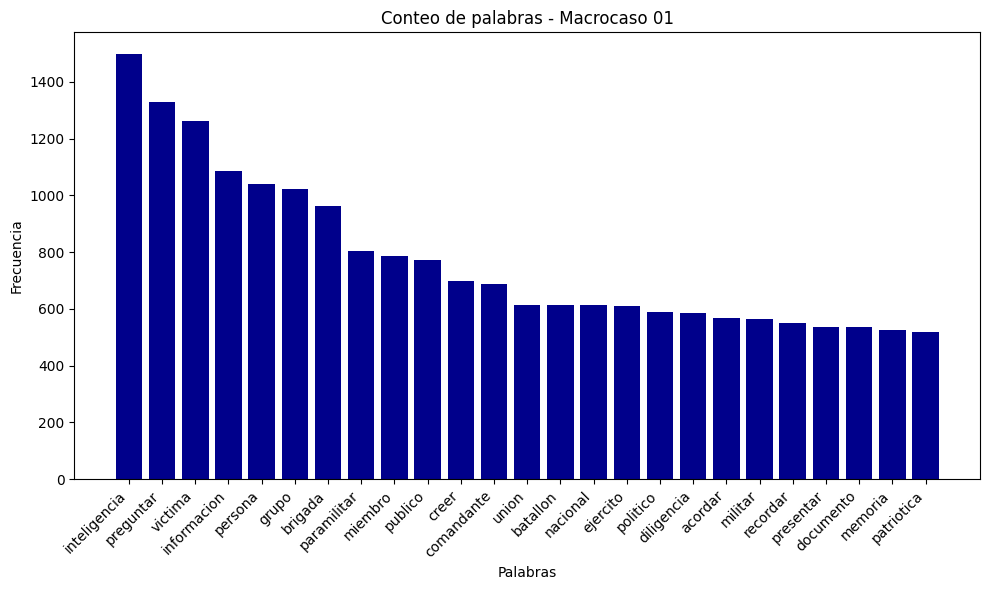

In [ ]:
#Distribución frecuencia términos:
tokens = nltk.word_tokenize(texto_sin_stopwords, language="spanish")
frecuencia_palabras = FreqDist(tokens)
palabras_repetidas = frecuencia_palabras.most_common(25)
palabras, frecuencias = zip(*palabras_repetidas)
plt.figure(figsize=(10, 6))
plt.bar(palabras, frecuencias, color="darkblue")
plt.xlabel('Palabras')
plt.ylabel('Frecuencia')
plt.title('Conteo de palabras - Macrocaso 01')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#Términos con mayor frecuencia
frecuencia_palabras = FreqDist(tokens)
palabras_repetidas = frecuencia_palabras.most_common(15)
tabla_frecuencias = pd.DataFrame(palabras_repetidas, columns=['Palabra', 'Frecuencia'])
print(tabla_frecuencias)

         Palabra  Frecuencia
0   inteligencia        1500
1      preguntar        1329
2        victima        1263
3    informacion        1085
4        persona        1039
5          grupo        1024
6        brigada         963
7    paramilitar         803
8        miembro         787
9        publico         774
10         creer         697
11    comandante         687
12         union         614
13      batallon         614
14      nacional         613


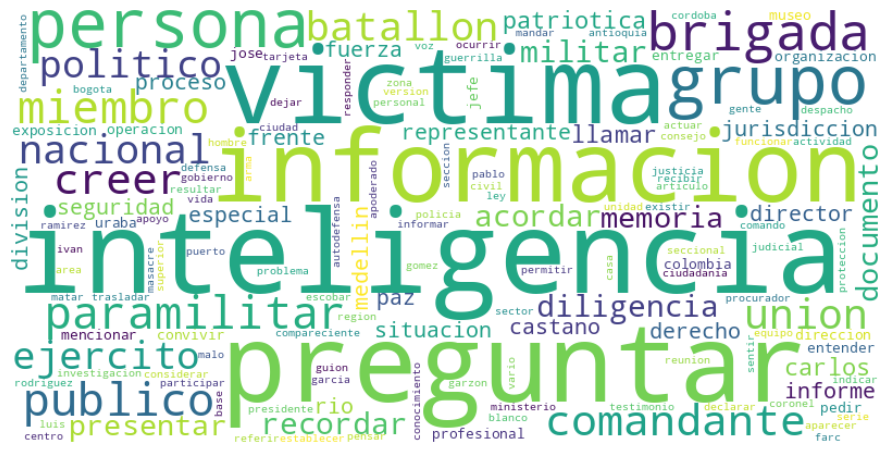

In [ ]:
# Nube de palabras:
frecuencia_palabras = FreqDist(tokens)
nube = WordCloud(width=800, height=400,
                 background_color='white',
                 #colormap='Dark2',
                 max_words=150).generate_from_frequencies(frecuencia_palabras)


plt.figure(figsize=(9, 5))
plt.imshow(nube, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()

# **ANÁLISIS DE SENTIMIENTO**

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

ruta_excel = "C:/Users/Desktop/Casos_JEP/emociones.xlsx"
lexico = pd.read_excel(ruta_excel, engine="openpyxl")

# Normalizar el léxico
lexico = lexico.rename(columns={'Spanish Translation': 'Palabra'})

def limpiar_palabra(p):
    if pd.isna(p):
        return ""
    p = unidecode(str(p).lower().strip())
    p = re.sub(r'[^a-zñáéíóúü\s]', '', p)
    p = re.sub(r'\s+', ' ', p)
    return p
lexico['Palabra'] = lexico['Palabra'].apply(limpiar_palabra)

columnas_emociones = ['Positive','Negative','Anger','Anticipation',
    'Disgust','Fear','Joy','Sadness','Surprise','Trust']

lexico[columnas_emociones] = lexico[columnas_emociones].fillna(0).astype(int)
lexico = lexico.groupby('Palabra', as_index=False)[columnas_emociones].max()
emociones = lexico.set_index('Palabra').to_dict(orient='index')

tokens = [limpiar_palabra(t) for t in word_tokenize(texto_sin_stopwords)]

conteo = Counter({emo: 0 for emo in columnas_emociones})

for token in tokens:
    if token in emociones:
        for emo, valor in emociones[token].items():
            conteo[emo] += valor

df_emociones = pd.DataFrame([conteo])
df_emociones.insert(0, 'Texto', 'audiencias')

# Traducir
traducciones = { 'Positive': 'Positivo', 'Negative': 'Negativo', 'Anger': 'Ira', 'Anticipation': 'Anticipación',
    'Disgust': 'Disgusto', 'Fear': 'Miedo', 'Joy': 'Alegría', 'Sadness': 'Tristeza', 'Surprise': 'Sorpresa',
    'Trust': 'Confianza'}

df_emociones = df_emociones.rename(columns=traducciones)
print(df_emociones)


        Texto  Positivo  Negativo   Ira  Anticipación  Disgusto  Miedo  \
0  audiencias     28536     15726  7868          9685      3794  13158   

   Alegría  Tristeza  Sorpresa  Confianza  
0     6727      7463      3930      22328  


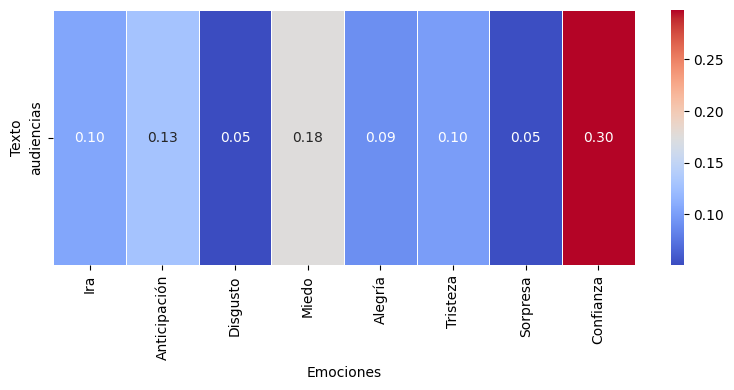

In [ ]:
#Gráfico de calor de emociones
columnas_emociones = ["Ira" , "Anticipación" , "Disgusto" ,  "Miedo",  "Alegría" , "Tristeza" , "Sorpresa", "Confianza"]
df_heatmap = df_emociones[['Texto'] + columnas_emociones].copy()
df_heatmap.set_index('Texto', inplace=True)
df_heatmap_norm = df_heatmap.div(df_heatmap.sum(axis=1), axis=0)
plt.figure(figsize=(8, 4))
sns.heatmap(df_heatmap_norm, cmap='coolwarm', annot=True, fmt=".2f", linewidths=.5)
plt.xlabel('Emociones')
plt.ylabel('Texto')
plt.tight_layout()
plt.show()


# **RED BASICA**

In [ ]:
# CREAR EL GRAFO NO DIRIGIDO
G = nx.Graph()
# Agregar nodos y aristas al grafo
for palabra1, palabra2 in skipgramas_limpio:
    G.add_edge(palabra1, palabra2)

nodo22 = list(G.edges())
len(nodo22)
print("Nodos en el grafo:", len(G.nodes))

Nodos en el grafo: 4409


In [ ]:
##Componente gigante:
componentes = sorted(nx.connected_components(G), key=len, reverse=True)
componente_gigante = componentes[0]
G_gigante = G.subgraph(componente_gigante).copy()

print("Nodos en componente gigante:", G_gigante.number_of_nodes())
print("Aristas en componente gigante:", G_gigante.number_of_edges())


Nodos en componente gigante: 4393
Aristas en componente gigante: 53357


In [ ]:
A = nx.to_pandas_adjacency(G_gigante, dtype=int)
#Metricas
A = nx.to_pandas_adjacency(G_gigante, dtype=int)
n = G_gigante.number_of_nodes()
m = G_gigante.number_of_edges()

grado_medio = np.mean([d for _, d in G_gigante.degree()])
grado_max = max(dict(G_gigante.degree()).values())
densidad = nx.density(G_gigante)

diametro = nx.diameter(G_gigante)
long_camino_prom = nx.average_shortest_path_length(G_gigante)

transitividad = nx.transitivity(G_gigante)
asortatividad = nx.degree_assortativity_coefficient(G_gigante)



In [ ]:
resumen = pd.DataFrame({
    "Métrica": [ "Número de nodos","Número de aristas","Grado medio","Grado máximo","Densidad",
        "Diámetro","Longitud media del camino","Transitividad","Asortatividad"],
    "Valor": [n,m, grado_medio,grado_max,densidad,diametro,long_camino_prom,transitividad,asortatividad]})
resumen


,Métrica,Valor
0,Número de nodos,4393.000000
1,Número de aristas,53357.000000
2,Grado medio,24.291828
3,Grado máximo,839.000000
4,Densidad,0.005531
5,Diámetro,7.000000
6,Longitud media del camino,2.946290
7,Transitividad,0.174843
8,Asortatividad,-0.145033


In [ ]:
centralidad_grado = nx.degree_centrality(G_gigante)
centralidad_intermediacion = nx.betweenness_centrality(G_gigante)
centralidad_cercania = nx.closeness_centrality(G_gigante)

In [ ]:
# Calcular grado de cada nodo
grados = dict(G_gigante.degree())
df_grados = (
    pd.DataFrame(grados.items(), columns=["termino", "grado"])
    .sort_values("grado", ascending=False)
    .reset_index(drop=True))
top_grado = df_grados.head(10)
top_grado

,termino,grado
0,preguntar,839
1,persona,772
2,inteligencia,749
3,victima,736
4,informacion,672
5,grupo,671
6,creer,584
7,brigada,555
8,miembro,528
9,paramilitar,522


In [ ]:
# Centralidad:

# Extraer la componente gigante
componentes = list(nx.connected_components(G))
componente_gigante = max(componentes, key=len)
G_gigante = G.subgraph(componente_gigante).copy()

print("Nodos en la componente gigante:", G_gigante.number_of_nodes())
print("Aristas en la componente gigante:", G_gigante.number_of_edges())

num_nodos = G_gigante.number_of_nodes()
num_aristas = G_gigante.number_of_edges()
grados = dict(G_gigante.degree())

# CENTRALIDAD

# Betweenness
betweenness = nx.betweenness_centrality( G_gigante, k=min(500, num_nodos), normalized=True, seed=42)

# Closeness
closeness = nx.closeness_centrality(G_gigante)

# Eigenvector
eigenvector = nx.eigenvector_centrality( G_gigante, max_iter=1000, tol=1e-6)
df_centralidad = pd.DataFrame({
    "termino": list(G_gigante.nodes()),
    "grado": [grados[n] for n in G_gigante.nodes()],
    "betweenness": [betweenness[n] for n in G_gigante.nodes()],
    "closeness": [closeness[n] for n in G_gigante.nodes()],
    "eigenvector": [eigenvector[n] for n in G_gigante.nodes()]
})


# TOP 10 POR CADA MÉTRICA
top10_grado = df_centralidad.sort_values("grado", ascending=False).head(10)
top10_betweenness = df_centralidad.sort_values("betweenness", ascending=False).head(10)
top10_closeness = df_centralidad.sort_values("closeness", ascending=False).head(10)
top10_eigenvector = df_centralidad.sort_values("eigenvector", ascending=False).head(10)

print("\n===== TOP 10 POR GRADO =====")
print(top10_grado)

print("\n===== TOP 10 POR BETWEENNESS =====")
print(top10_betweenness)

print("\n===== TOP 10 POR CLOSENESS =====")
print(top10_closeness)

print("\n===== TOP 10 POR EIGENVECTOR =====")
print(top10_eigenvector)

Nodos en la componente gigante: 4393
Aristas en la componente gigante: 53357

===== TOP 10 POR GRADO =====
          termino  grado  betweenness  closeness  eigenvector
161     preguntar    839     0.049267   0.530948     0.138897
139       persona    772     0.042452   0.526871     0.134326
218  inteligencia    749     0.041889   0.516402     0.124393
43        victima    736     0.045084   0.511709     0.116696
302   informacion    672     0.036276   0.514708     0.122359
252         grupo    671     0.041204   0.514045     0.120544
91          creer    584     0.029509   0.511114     0.114104
343       brigada    555     0.030466   0.499204     0.105312
18        miembro    528     0.023432   0.499716     0.108191
285   paramilitar    522     0.022164   0.498242     0.104691

===== TOP 10 POR BETWEENNESS =====
          termino  grado  betweenness  closeness  eigenvector
161     preguntar    839     0.049267   0.530948     0.138897
43        victima    736     0.045084   0.511709   